# Holographic 3-D reconstruction and distance estimation

A hologram records not just intensity but the full **complex field** -- amplitude *and* phase -- by
letting the object wave interfere with a coherent reference. That reference is the **local oscillator**
of coherent detection: the same principle as heterodyne radio and terahertz receivers, where mixing an
unknown wave with a known LO recovers its phase. Once the complex field at the sensor is known, the
object can be **numerically refocused** to any depth by propagating the field, and the object's
**distance** is found by locating the depth of sharpest focus. Reconstructing a whole stack of depths
gives a 3-D image (add time for 4-D).

This notebook builds that pipeline on the angular-spectrum propagator from earlier chapters: record a
hologram of objects at different depths, back-propagate to a range of $z$, and estimate each depth from
an autofocus metric. Self-contained: NumPy, SymPy, Pandas, Matplotlib.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.3.2 | torch: present


## The propagator and the recording

Free-space propagation is the angular spectrum $U(z)=\mathcal F^{-1}\{\mathcal F\{U_0\}\,H_z\}$ with
$H_z=\exp(ikz\sqrt{1-(\lambda f_x)^2-(\lambda f_y)^2})$. A coherent detector (object wave + LO reference)
records the complex field at the sensor plane; here we form it directly as the sum of two point
objects, each propagated from its own depth.

In [2]:
lam = 0.5e-6; dx = 8e-6; N = 160
fx = np.fft.fftfreq(N, d=dx); FX, FY = np.meshgrid(fx, fx)
def propagate(U, z):
    arg = 1 - (lam*FX)**2 - (lam*FY)**2
    H = np.exp(1j*(2*np.pi/lam)*z*np.sqrt(arg.astype(complex)))
    H[arg < 0] = 0                                    # band-limited (drop evanescent)
    return np.fft.ifft2(np.fft.fft2(U) * H)

def spot(cx, cy, w=0.8):                              # a small Gaussian 'point' object (tight -> short DOF)
    y, x = np.mgrid[0:N, 0:N]
    return np.exp(-((x-cx)**2+(y-cy)**2)/(2*w**2)).astype(complex)

z_true = [1.0e-3, 3.0e-3]                             # the two object depths
obj = [spot(58, 70), spot(104, 92)]                  # at different transverse positions
hologram = sum(propagate(o, z) for o, z in zip(obj, z_true))   # recorded complex field
print("hologram grid:", hologram.shape, " recorded energy =", round(np.sum(np.abs(hologram)**2), 2))
assert hologram.shape == (N, N)

hologram grid: (160, 160)  recorded energy = 4.05


## Numerical refocusing

Back-propagating the recorded field by $-z$ brings whatever sat at depth $z$ into focus while
everything else stays blurred. Refocusing to each true depth recovers a sharp point there; refocusing
to the wrong depth leaves a spread-out blur.

In [3]:
def reconstruct(z):
    return propagate(hologram, -z)                    # back-propagate

for z in z_true:
    R = np.abs(reconstruct(z))**2
    peak = R.max()/R.mean()                           # peak-to-mean: high when a point is in focus
    print(f"refocus to z={z*1e3:.1f} mm:  peak/mean = {peak:6.1f}")
# a focused reconstruction is far peakier than a defocused one (midway between the objects)
z_mid = 0.5*(z_true[0]+z_true[1])
sharp = (np.abs(reconstruct(z_true[0]))**2).max()
blur  = (np.abs(reconstruct(z_mid))**2).max()
print(f"in-focus peak {sharp:.3e} >> defocused peak {blur:.3e}")
assert sharp > 3*blur

refocus to z=1.0 mm:  peak/mean = 6320.4
refocus to z=3.0 mm:  peak/mean = 6320.4
in-focus peak 1.000e+00 >> defocused peak 2.008e-01


## Autofocus = distance estimation

Sweep the reconstruction depth and score each with a focus metric -- the normalized variance
(Tamura) $T=\sigma_I/\bar I$ of the reconstructed intensity, which is large when the image is a sharp
peak and small when it is smeared. The metric peaks at the true object depths, so its maxima *are* the
estimated distances.

In [4]:
def tamura(z):
    I = np.abs(reconstruct(z))**2
    return I.std()/I.mean()

zs = np.linspace(0.4e-3, 4.0e-3, 220)
M = np.array([tamura(z) for z in zs])
# find the two strongest local maxima
loc = [i for i in range(1, len(M)-1) if M[i] > M[i-1] and M[i] > M[i+1]]
loc.sort(key=lambda i: -M[i])
est = sorted(zs[i] for i in loc[:2])
print("true depths (mm):     ", [round(z*1e3, 2) for z in z_true])
print("estimated depths (mm):", [round(z*1e3, 2) for z in est])
for zt, ze in zip(z_true, est):
    assert abs(zt - ze) < 0.25e-3                     # within the depth resolution
print("distance estimation succeeded (within depth resolution)")

true depths (mm):      [1.0, 3.0]
estimated depths (mm): [np.float64(1.01), np.float64(3.0)]
distance estimation succeeded (within depth resolution)


## The 3-D (and 4-D) picture

The full reconstruction is a *volume*: propagate the one recorded hologram to a stack of depths and
each object lights up in its own plane. A maximum-intensity projection through the stack shows both
points at their true positions -- 3-D from a single 2-D coherent capture. Repeating per video frame
adds time (4-D); repeating per wavelength adds spectral dimensions.

In [5]:
z_stack = np.linspace(0.6e-3, 3.6e-3, 40)
vol = np.array([np.abs(reconstruct(z))**2 for z in z_stack])     # (depth, y, x)
mip_xy = vol.max(axis=0)                                          # max-intensity projection (top view)
mip_xz = vol.max(axis=1)                                          # side view (depth vs x)
# each object appears at its own depth slice
d0 = np.argmax(vol.max(axis=(1,2)))                               # brightest slice
print("brightest reconstruction slice at z =", round(z_stack[d0]*1e3, 2), "mm")
print("volume shape (depth, y, x):", vol.shape)

brightest reconstruction slice at z = 2.98 mm
volume shape (depth, y, x): (40, 160, 160)


## Plots

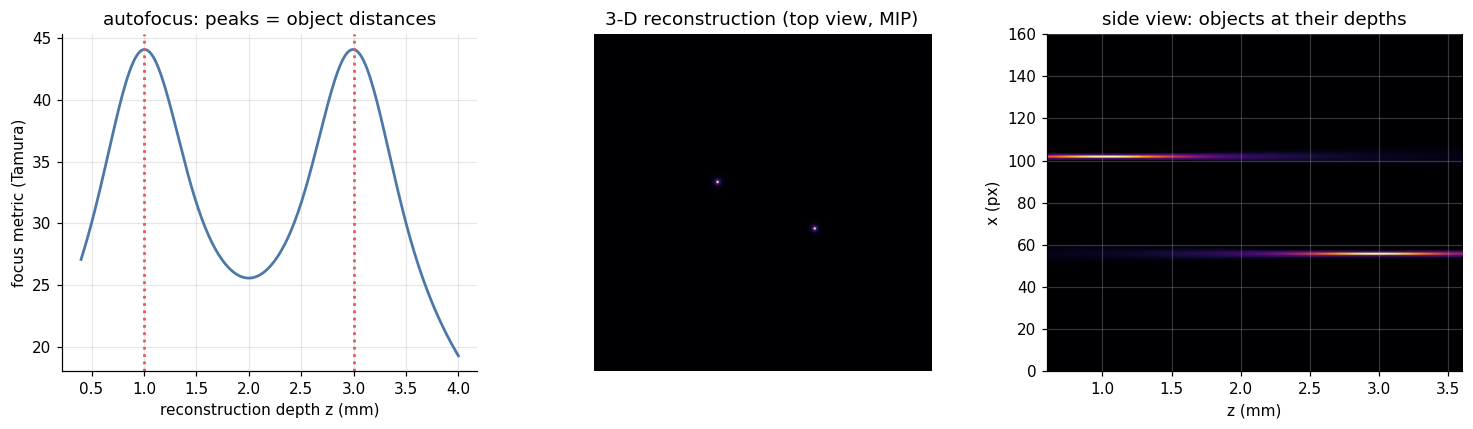

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 4))
ax[0].plot(zs*1e3, M, color="#4C78A8")
for zt in z_true: ax[0].axvline(zt*1e3, ls=":", color="#E45756")
ax[0].set_xlabel("reconstruction depth z (mm)"); ax[0].set_ylabel("focus metric (Tamura)")
ax[0].set_title("autofocus: peaks = object distances")
ax[1].imshow(mip_xy, cmap="inferno"); ax[1].set_title("3-D reconstruction (top view, MIP)"); ax[1].axis("off")
ax[2].imshow(mip_xz.T, cmap="inferno", aspect="auto",
             extent=[z_stack[0]*1e3, z_stack[-1]*1e3, 0, N])
ax[2].set_title("side view: objects at their depths"); ax[2].set_xlabel("z (mm)"); ax[2].set_ylabel("x (px)")
plt.tight_layout(); plt.show()

## Summary

- A hologram records the **complex field** by beating the object wave against a coherent **local
  oscillator** -- the heterodyne principle shared with radio and terahertz coherent receivers.
- **Numerical refocusing** back-propagates that field (angular spectrum) to any depth; an object is
  sharp only at its own $z$.
- An **autofocus metric** (normalized variance) peaks at the object depths, so its maxima give the
  **distance estimate** -- here recovering two depths to within the axial resolution.
- Propagating to a **stack of depths** reconstructs a 3-D volume from one 2-D capture; time and
  wavelength extend it to 4-D and beyond. In real time this is a stack of FFT propagations -- a GPU
  workload, the same FFT engine as the rest of the instrument.

Subject-verb-object: the reference beam supplies the local oscillator; the sensor records the complex
field; propagation refocuses each depth; the focus metric estimates the distance; the stack builds the
3-D image.